**Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../data/processed', exist_ok=True)
%matplotlib inline

import xgboost as xgb
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed/application_processed.csv')
X  = df.drop(columns=['TARGET'])
y  = df['TARGET']

# Clean column names, remove any special characters
X.columns = [str(c).replace('[','').replace(']','').replace('<','') 
             for c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# Retrain
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("Model retrained.")
print(f"Features: {X_train.shape[1]}")

Model retrained.
Features: 83


**Build SHAP Explainer**

In [2]:
explainer = shap.TreeExplainer(xgb_model)

sample_idx  = X_test.sample(2000, random_state=42).index
X_sample    = X_test.loc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Sample size: {len(X_sample)}")

SHAP values shape: (2000, 83)
Sample size: 2000


**Global Feature Importance**

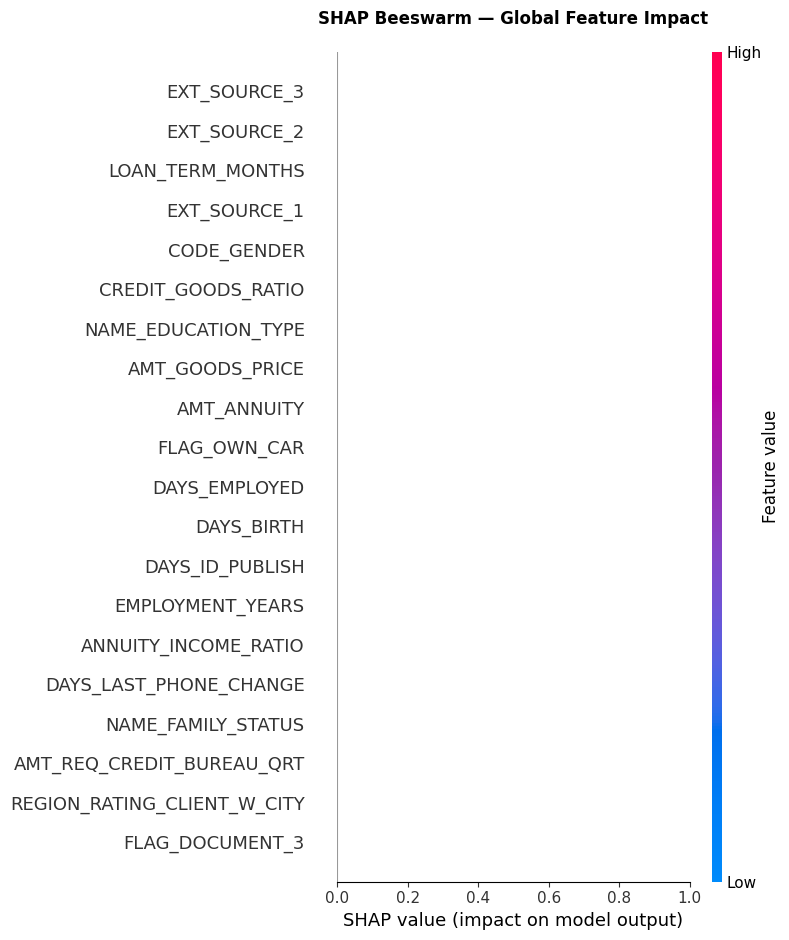

In [3]:
plt.figure()
shap.summary_plot(
    shap_values, X_sample,
    plot_type='beeswarm',
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — Global Feature Impact', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/10_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

**SHAP Bar Summary**

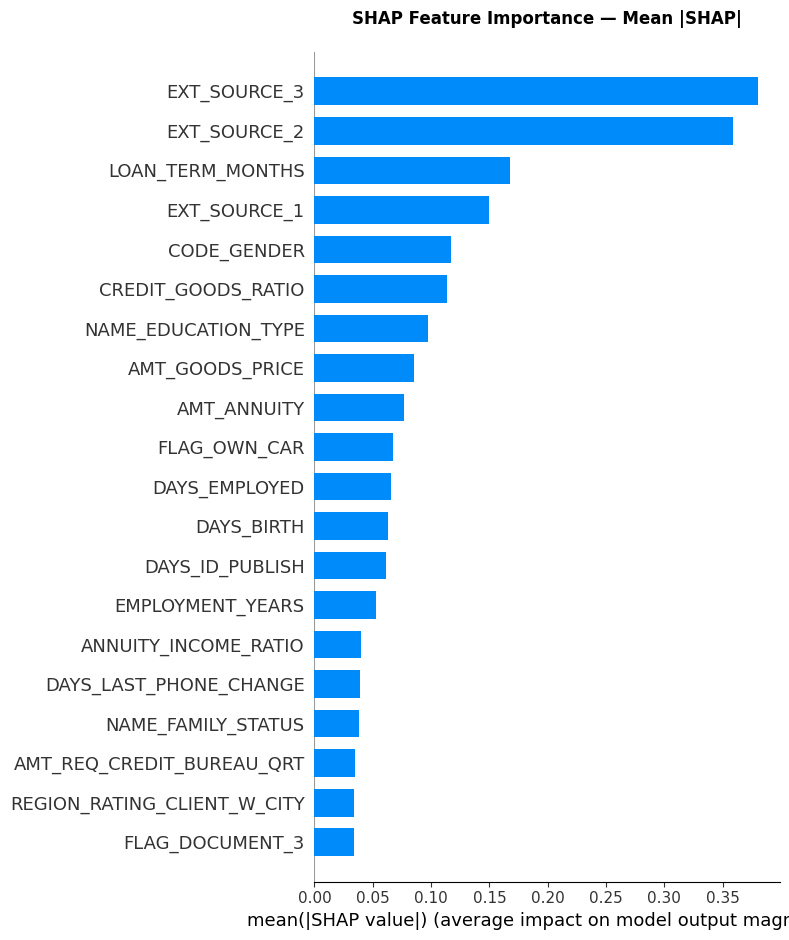

In [4]:
plt.figure()
shap.summary_plot(
    shap_values, X_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — Mean |SHAP|', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/processed/11_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Individual Applicant Explanation**

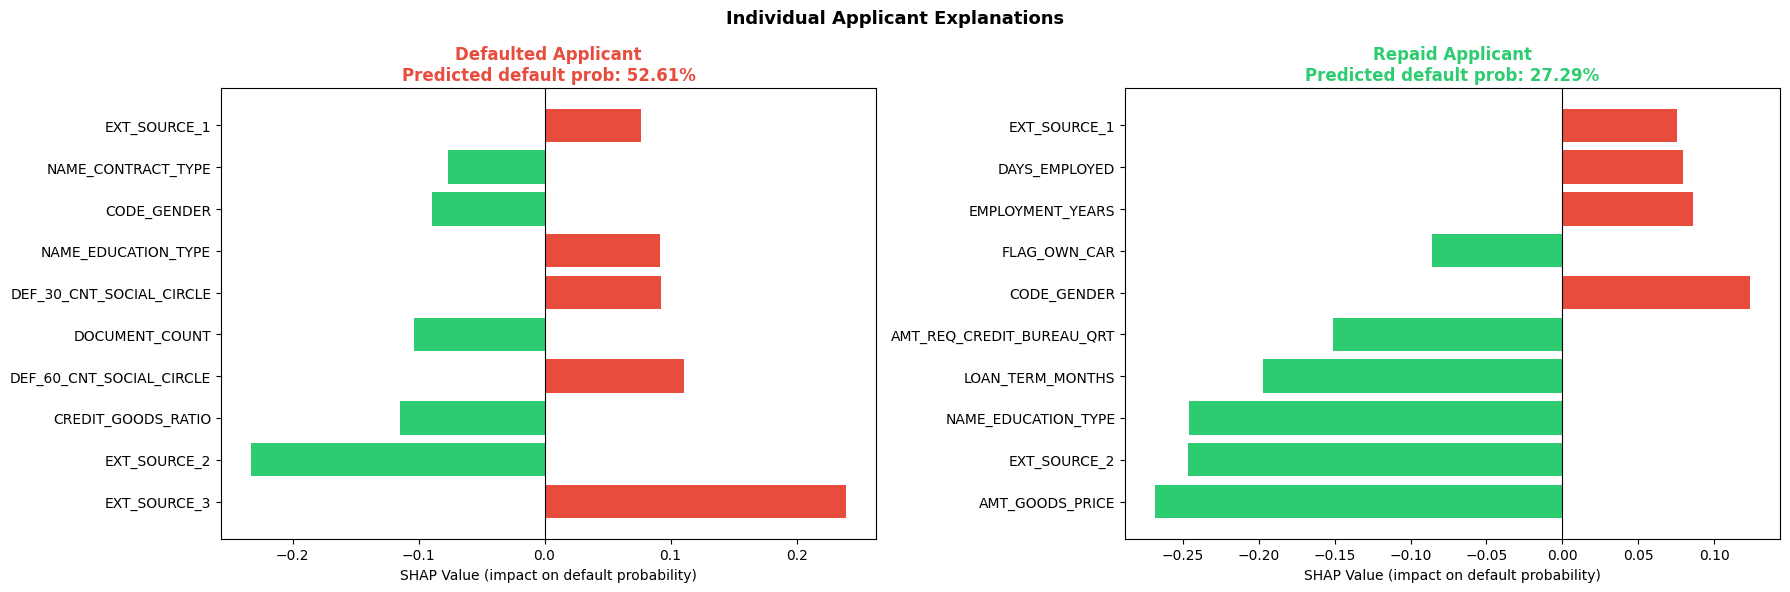

In [5]:
# Pick one defaulted applicant and one repaid for contrast
defaulted_idx = y_test[y_test == 1].index[0]
repaid_idx    = y_test[y_test == 0].index[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, idx, label, color in zip(
    axes,
    [defaulted_idx, repaid_idx],
    ['Defaulted Applicant', 'Repaid Applicant'],
    ['#e74c3c', '#2ecc71']
):
    applicant    = X_test.loc[[idx]]
    shap_vals    = explainer.shap_values(applicant)
    expected_val = explainer.expected_value

    # Top contributing features for this applicant
    contributions = pd.DataFrame({
        'feature'     : X.columns,
        'shap_value'  : shap_vals[0],
        'feature_value': applicant.values[0]
    }).reindex(
        pd.Series(shap_vals[0]).abs().sort_values(ascending=False).index
    ).head(10)

    colors = ['#e74c3c' if v > 0 else '#2ecc71' 
              for v in contributions['shap_value']]
    
    ax.barh(contributions['feature'], contributions['shap_value'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{label}\nPredicted default prob: '
                 f'{xgb_model.predict_proba(applicant)[0,1]:.2%}',
                 fontweight='bold', color=color)
    ax.set_xlabel('SHAP Value (impact on default probability)')

plt.suptitle('Individual Applicant Explanations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/12_shap_individual.png', dpi=150, bbox_inches='tight')
plt.show()

**SHAP Dependence Plots**

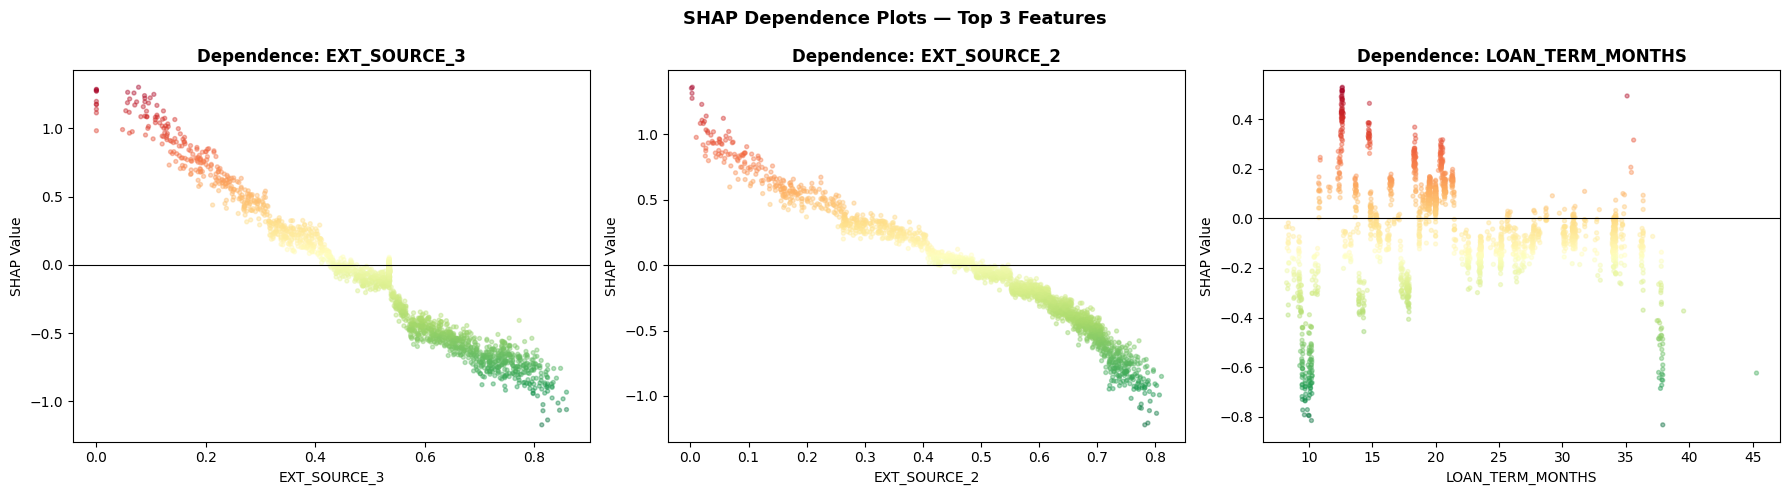

In [6]:
# Get top 3 features by mean |SHAP|
mean_shap    = np.abs(shap_values).mean(axis=0)
top3_idx     = mean_shap.argsort()[::-1][:3]
top3_features = X_sample.columns[top3_idx].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, top3_features):
    feat_idx = list(X_sample.columns).index(feat)
    ax.scatter(
        X_sample[feat],
        shap_values[:, feat_idx],
        c=shap_values[:, feat_idx],
        cmap='RdYlGn_r', alpha=0.4, s=8
    )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP Value')
    ax.set_title(f'Dependence: {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/13_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

**Save SHAP Values & Print Summary**

In [7]:
# Save SHAP values for use in the RAG agent later
shap_df = pd.DataFrame(shap_values, columns=X_sample.columns)
shap_df.to_csv('../data/processed/shap_values_sample.csv', index=False)

# Global feature ranking by mean |SHAP|
shap_importance = pd.DataFrame({
    'feature'        : X_sample.columns,
    'mean_abs_shap'  : np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

shap_importance.to_csv('../data/processed/shap_feature_importance.csv', index=False)

print("Saved:")
print("  → data/processed/shap_values_sample.csv")
print("  → data/processed/shap_feature_importance.csv")
print()
print("Top 10 features by mean |SHAP|:")
print(shap_importance.head(10).to_string(index=False))

Saved:
  → data/processed/shap_values_sample.csv
  → data/processed/shap_feature_importance.csv

Top 10 features by mean |SHAP|:
            feature  mean_abs_shap
       EXT_SOURCE_3       0.380082
       EXT_SOURCE_2       0.358987
   LOAN_TERM_MONTHS       0.167507
       EXT_SOURCE_1       0.149861
        CODE_GENDER       0.116935
 CREDIT_GOODS_RATIO       0.113757
NAME_EDUCATION_TYPE       0.097669
    AMT_GOODS_PRICE       0.085751
        AMT_ANNUITY       0.076857
       FLAG_OWN_CAR       0.067150
